# Illustration of simple stock-rollover dynamics in light-duty vehicle sector
We will create a simple stock-rollover model to explore the complementary roles of vehicle electrification and vehicle miles travel (VMT) reduction.

In [1]:
# setup
import numpy as np # Core numerical and array operations
import pandas as pd # Data table and analysis operations
import matplotlib.pyplot as plt # Plotting; syntax and appearance similar to Matlab
import pathlib # file handling robust to switching between Mac, PC, and Linux platforms

## 1) Create our stock-rollover model.

First, we'll pick a time range. Let's create a year vector that ranges from 2010 to 2055.
(You'll see below why we need to start in the past.)

In [2]:
yyyy = np.arange(2010, 2056) # Remember that array indices run from 0 to n-1, where n is the range length.
# So this will stop in year 2055.
# The syntax here is assign variable yyyy to what is returned from the np member function arange, passing arguments 2010 and 2056.

# List:
yyyy

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031,
       2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042,
       2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053,
       2054, 2055])

Text(0, 0.5, 'Calendar Year')

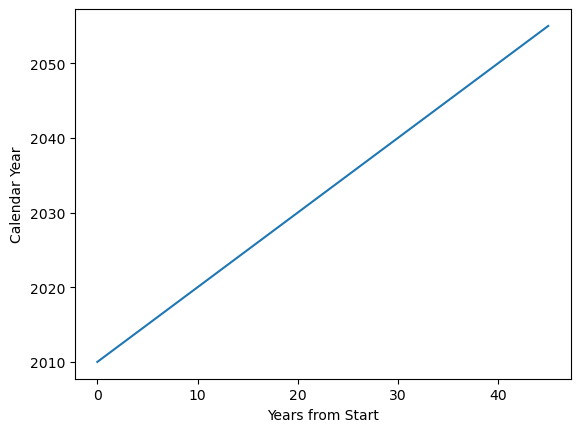

In [3]:
# Plot
plt.plot(yyyy)
plt.xlabel('Years from Start') # It inferred the x-axis
plt.ylabel('Calendar Year')

Let's keep it real simple and assume a constant vehicle fleet size for the US of 300 million vehicles.
You can get a more precise projection from [AEO Table 39](https://www.eia.gov/outlooks/aeo/data/browser/#/?id=49-AEO2026&cases=cb2026&sourcekey=0).

In [4]:
n_total_vehicles = 3e8 # i.e. 3 x 10^8 or 300 million

And still keeping it real simple, let's assume the simplest realistic survival profile for each vehicle.
Let's say each vehicle stays on the road (being driven the same number of annual miles) for exactly 15 years and then is scrapped.
A more sophisticated survival profile would be a [Weibull Distribution](https://en.wikipedia.org/wiki/Weibull_distribution) with
a [shape parameter around 2](https://www.sciencedirect.com/science/article/pii/S2590198226002964) -- most vehicles last a few years
but then their likelihood of being retired starts to grow after a decade; this would modestly complicate the equations below but
not change the conclusions this exercise illustrates.

In [5]:
vehicle_life = 15 # yr

And we'll assume just two types of vehicles, gas\[oline\] and electric.

We need an initial condition. Let's seed our vehicle fleet in year 2010 with 300 million gasoline vehicles.
But first we'll need to create the container for our fleet projections.

In [6]:
# Create empty Dataframe with index of years and our vehicle stock columns.
fuels = ['gas', 'EV'] # this is a native python list structure
vehicle_stock = pd.DataFrame(index=yyyy, columns=fuels, data=np.nan) # canonical DataFrame constructor function
vehicle_stock.head() # Show what the first 5 rows look like

,gas,EV
2010,NaN,NaN
2011,NaN,NaN
2012,NaN,NaN
2013,NaN,NaN
2014,NaN,NaN


We haven't filled in any data so it starts as NaN.
Now we seed the first year.

In [7]:
vehicle_stock.loc[2010, 'gas'] = n_total_vehicles
# .loc is the syntax for accessing a row. You can access a column with simple brackets but a complete .loc[rows, cols] is preferred when you are assigning values.
vehicle_stock.loc[2010, 'EV'] = 0
vehicle_stock.head()

,gas,EV
2010,300000000.0,0.0
2011,NaN,NaN
2012,NaN,NaN
2013,NaN,NaN
2014,NaN,NaN


To advance from one year to the next, we'll need to track vehicle sales.
Since we're assuming a constant vehicle fleet and the simple survival profile, the total sales
each year will be exactly 1/15 times the fleet size.

In [8]:
n_total_sales = n_total_vehicles / 15 # vehicles per yr
print(np.format_float_scientific(n_total_sales)) # to avoid having to count zeros

2.e+07


That's 20M vehicles per year.

In [9]:
vehicle_sales = pd.DataFrame(index=yyyy, columns=fuels, data=np.nan)
# Create a vehicle sales dataframe with the same shape.

vehicle_sales.loc[2010, 'gas'] = n_total_sales
vehicle_sales.loc[2010, 'EV'] = 0
vehicle_sales.head()

,gas,EV
2010,20000000.0,0.0
2011,NaN,NaN
2012,NaN,NaN
2013,NaN,NaN
2014,NaN,NaN


Now the key step is to advance the stocks from year to year. To do that, we'll retire all the vehicles
that were sold 15 years ago and then add the previous year's sales.
To make this easy, we'll assume zero EVs sold for the first 15 years.

In [10]:
vehicle_stock.loc[yyyy[:15], fuels] = [n_total_vehicles, 0]
# This is a complicated expression to illustrate more sophisticated pandas syntax.
# We are assigning the identical rows in bulk in 1 line. We could have written up to 30 statements here if we wanted to be verbose:
# 15 separate lines for each year (like we did above), times 2 lines for each column.

# The shape on the left side is 15 rows by 2 columns, and on the right is 1 row by 2 columns, so pandas infers that you want to
# duplicate the row 15 times. Often it figures out what you want to do in this way but sometimes it is less intuitive.
# In general the syntax being used is x.loc[ROW_RANGE, COLUMN_RANGE] = VALS
# Don't forget that fuels is actually a list of two values.

vehicle_stock.head(15) # Show the first 15 rows

,gas,EV
2010,300000000.0,0.0
2011,300000000.0,0.0
2012,300000000.0,0.0
2013,300000000.0,0.0
2014,300000000.0,0.0
2015,300000000.0,0.0
2016,300000000.0,0.0
2017,300000000.0,0.0
2018,300000000.0,0.0
2019,300000000.0,0.0


In [11]:
vehicle_sales.loc[2010]

gas    20000000.0
EV            0.0
Name: 2010, dtype: float64

In [12]:
# Do the same thing for sales, but go through 2025
# This time we'll demonstrate just setting it equal to the first row.
vehicle_sales.loc[yyyy[:16], fuels] = vehicle_sales.loc[2010].values
# Using yyyy[:16] we're referencing the first 15 years: that means subset the array to its first 15 indices only.

# By leaving out the column range on the right, it infers we want to broadcast to whole rows. But you have to use the ".values" so pandas interprets the shape correctly.
# This part can sometimes take trial and error. (I had to ask a chatbot for help getting the syntax right in this case!) You can always
# fall back on doing it element by element and use for-loops in a pinch. Just note this is less efficient if you have much larger data because the built-in
# functions call pre-compiled C libraries, so you're calling these libraries many times rather than just once.

vehicle_sales.head(16)

,gas,EV
2010,20000000.0,0.0
2011,20000000.0,0.0
2012,20000000.0,0.0
2013,20000000.0,0.0
2014,20000000.0,0.0
2015,20000000.0,0.0
2016,20000000.0,0.0
2017,20000000.0,0.0
2018,20000000.0,0.0
2019,20000000.0,0.0


OK now beginning in year 2025, we're going to set the stock based on the sales from the previous year,
subtracting the vehicles sold 15 yr ago.
We could make this more elegant and efficient using a function and operating on the entire dataframe at once,
but we'll demonstrate using a simple for-loop.

But first let's just do year 2025.

In [13]:
vehicle_stock.loc[2025, 'gas'] = vehicle_stock.loc[2024, 'gas'] - vehicle_sales.loc[2025 - vehicle_life, 'gas'] + vehicle_sales.loc[2025, 'gas']
# Last year's stock - Retirement + This year's sales
# In this simple case we're basically just subbing in old sales for new sales.
# To make the units match, we're implicitly multiplying by 1 year here, so we have vehicles + delta vehicles/yr * yr = vehicles.

# Do the same for electric
vehicle_stock.loc[2025, 'EV'] = vehicle_stock.loc[2024, 'EV'] - vehicle_sales.loc[2025 - vehicle_life, 'EV'] + vehicle_sales.loc[2025, 'EV']

vehicle_stock.loc[2025]

gas    300000000.0
EV             0.0
Name: 2025, dtype: float64

Now we need to assume a sales trajectory for our projection. This is the first _scenario_ assumption we're making,
as opposed to defining a simple baseline model from first principles.

This is typically modeled using an [S-curve](https://en.wikipedia.org/wiki/Sigmoid_function).
To simplify, we'll use a piecewise linear function, increasing 1M/yr (5% of sales) each yr from 2025 to 2030, then 2M/yr for the next 5 yr,
and then 1M/yr to 2040.

This approximately means the whole country meets CA's 2035 zero emission vehicle standards (which is facing some market and political uncertainty in 2026) 5 years later.

Let's define a dimensionless `sales_share_EV variable` to make this easier.

Text(0, 0.5, 'EV Sales Share (fraction)')

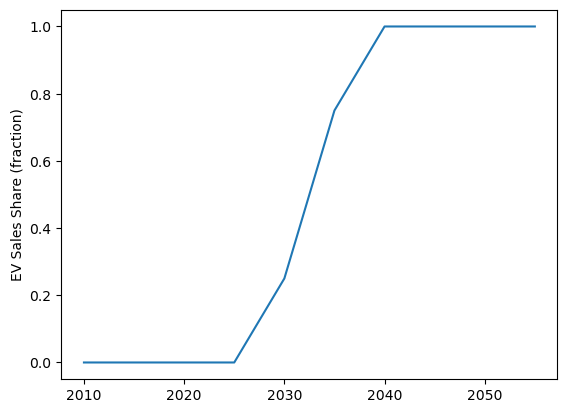

In [14]:
sales_share_EV = pd.Series(index=yyyy) # canonical Series constructor: a Series is a single column of a DataFrame (a np array with some metadata).
sales_share_EV.loc[:2025] = 0
sales_share_EV.loc[2026:2029] = np.arange(0.05, 0.25, 0.05) # You can use arange for floats. The syntax is (start, stop, step).
# REMEMBER this uses the 0-index array convention so assigns 2026 through 2028, and does NOT assign 2029.
sales_share_EV.loc[2030:2034] = np.arange(0.25, 0.75, 0.1)
sales_share_EV.loc[2035:2039] = np.arange(0.75, 1, 0.05)
sales_share_EV.loc[2040:2056] = 1
sales_share_EV.plot()
plt.ylabel('EV Sales Share (fraction)')

You could also plot it as % in 1 step:

Text(0, 0.5, '% EV Sales Share')

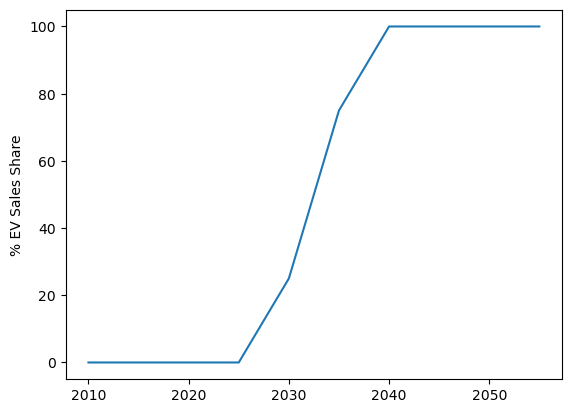

In [15]:
(sales_share_EV * 100).plot() # By using the parentheses, you create a new temporary DataFrame with values multiplied by 100,
# and then you call its member function "plot".
plt.ylabel('% EV Sales Share')

Let's multiply this through to finish defining our vehicle_sales variable.

In [16]:
vehicle_sales.loc[:, 'gas'] = (1 - sales_share_EV) * n_total_sales
vehicle_sales.loc[:, 'EV'] = sales_share_EV * n_total_sales

# The ":" means fill all rows here.

We could have done this in one line if we had defined a `sales_share` variable generically with the same `fuels` dimensions as the
other variables and constrained it to add to 1.

Let's plot and make sure we got what we wanted!
The built-in pandas plot function (an interface which passes its content to matplotlib) is convenient here: it will build a legend using the columns.

Divide by 1e6 to show million vehicles per year.

Text(0, 0.5, 'Million Vehicles Per Year')

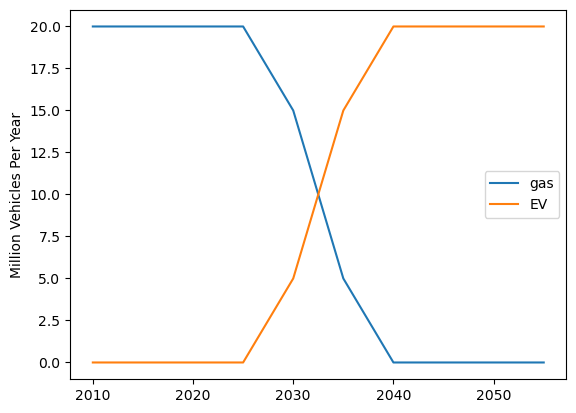

In [17]:
(vehicle_sales / 1e6).plot() # Using parentheses converts this into a new pandas dataframe to use the member function "plot."
# This is actually an interface for matplotlib.plt with information about the shape passed in.

plt.ylabel('Million Vehicles Per Year')

Now we're ready to evaluate the stock-rollover from 2026-2055!

We'll add a bit of generality using two for loops for years and combining the gas and EV into one expression.

Text(0.5, 1.0, 'US Vehicle Fleet Assuming 100% EV Sales by 2040')

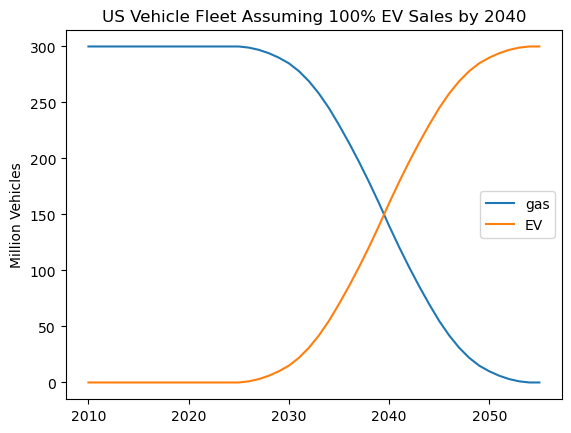

In [18]:
for y in np.arange(2026, 2056):
    for f in fuels:
        vehicle_stock.loc[y, f] = vehicle_stock.loc[y - 1, f] - vehicle_sales.loc[y - vehicle_life, f] + vehicle_sales.loc[y, f]
        # This year's stock = Last year's stock - Retirement + This year's sales
        
        # This will throw an error if you started with too early a year, and it tries to access y - vehicle_life
        # before the start of the time period.

# Plot!

(vehicle_stock / 1e6).plot()
plt.ylabel('Million Vehicles')
plt.title('US Vehicle Fleet Assuming 100% EV Sales by 2040')

**So even in this simple model, there are still many gas vehicles in the fleet through 2045!**

We can also look at a stacked area plot.

Text(0.5, 1.0, 'US Vehicle Fleet Assuming 100% EV Sales by 2040')

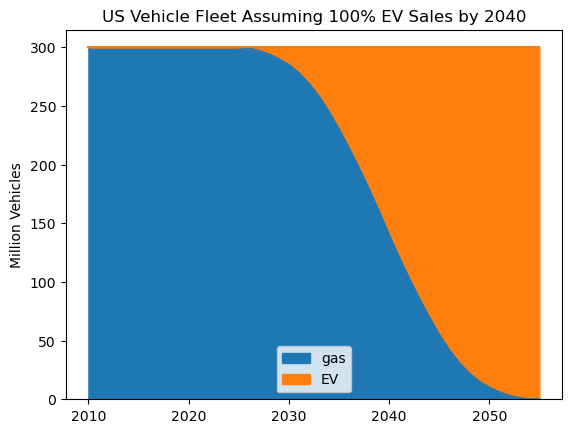

In [19]:
(vehicle_stock / 1e6).plot(kind='area', stacked=True)
plt.ylabel('Million Vehicles')
plt.title('US Vehicle Fleet Assuming 100% EV Sales by 2040')

Let's save our beautiful figure locally. We'll create an output directory that matches the repository's "gitignore" configuration so it
will not be pushed to github.

In [20]:
outputdir = pathlib.Path().cwd() / 'outputdata' # Create a pathlib object aligned with the current working directory.
outputdir.mkdir(exist_ok=True) # Create the new output directory if it doesn't already exist.
print(outputdir)

/Users/subin/Code/usf-engy680-urban-energy-fall2026/example_notebooks/outputdata


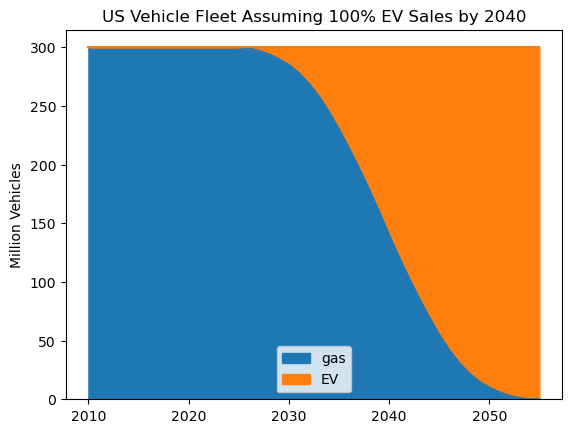

In [21]:
(vehicle_stock / 1e6).plot(kind='area', stacked=True)
plt.ylabel('Million Vehicles')
plt.title('US Vehicle Fleet Assuming 100% EV Sales by 2040')
plt.savefig(outputdir / 'VehicleStock_100pEVsalesIn2040.svg') # You can use common formats here as the file suffix: png, pdf, jpg, etc.

For comparison, let's make a stacked-area version of the sales plot.

Text(0.5, 1.0, 'US Vehicle Sales, Ramping from 0 to 100% EV Sales from 2025 to 2040')

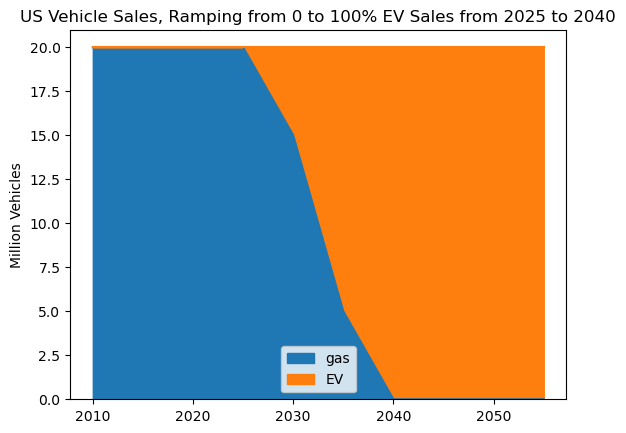

In [22]:
(vehicle_sales / 1e6).plot(kind='area', stacked=True)
plt.ylabel('Million Vehicles')
plt.title('US Vehicle Sales, Ramping from 0 to 100% EV Sales from 2025 to 2040')

You can see comparing the two plots how the sales transition leads the stock transition by a decade or so.

To summarize, we can ask what the average year's sales and fleet mix is from 2026 onward.
Remember that we're starting an aggressive EV sales trajectory beginning in 2026.

In [23]:
(vehicle_sales / 1e6).loc[2026:].mean()
# This means from year 2026 until end of period.
# The mean function, like most "aggfunc" or aggregation functions in pandas, defaults to aggregating the rows in each column.
# If you wanted to instead aggregate the columns in each row, you would pass the optional argument "axis=1".

gas     4.666667
EV     15.333333
dtype: float64

In [24]:
# Making it dimensionless to get an average sales share:
vehicle_sales.loc[2026:].sum() / vehicle_sales.loc[2026:].sum().sum()
# Once you've aggregated once, it assumes the next aggregation is across the remaining dimension.

gas    0.233333
EV     0.766667
dtype: float64

So we're selling 77% EVs in an average year from now on.
But environmental impacts don't care about the sales, they care about the stock.

In [25]:
(vehicle_stock / 1e6).loc[2026:].mean()

gas    140.0
EV     160.0
dtype: float64

In [26]:
vehicle_stock.loc[2026:].sum() / vehicle_stock.loc[2026:].sum().sum()

gas    0.466667
EV     0.533333
dtype: float64

So despite the 77% EV sales, we will still have 47% of the environmental impacts from the gas vehicles
integrated over this time frame.

In the next step, we'll make this explicit.

## 2) Greenhouse gas emission implications

To start, let's focus only on the direct, tailpipe emissions from the gasoline vehicles.

We'll assume each vehicle gets 25 miles per gallon (mpg) and drives 10,000 miles per year.
You can get more precise projections from [AEO Table 7](https://www.eia.gov/outlooks/aeo/data/browser/#/?id=7-AEO2026&cases=cb2026&sourcekey=0).

We can convert this to tonnes of CO$_2$ per vehicle, per year, using direct [emissions factors](https://www.epa.gov/climateleadership/ghg-emission-factors-hub) from EPA.
(We'll ignore the trace non-CO$_2$ pollution from combustion here and in the global carbon budget considerations.)

In [27]:
gas_ghgs_pergallon = 8.78 # kg CO2e per gallon from the "motor gasoline" row. We're ignoring ethanol content and CA-specific blend here.

# Convert to tonnes:
gas_ghgs_tpergal = gas_ghgs_pergallon / 1000 # kg CO2e per gallon / (kg per tonne) = tonnes CO2e per gallon

# Use mpg to get tonnes per mile:
mpg = 25
gas_ghgs_tpermi = gas_ghgs_tpergal / mpg # t per gallon / (mi per gallon) = t per mi

# Finally, multiply by mi per year, per vehicle to get tonnes per vehicle.
vmt_per_vehicleyr = 1e4
tco2_per_vehicleyr = gas_ghgs_tpermi * vmt_per_vehicleyr # t per mi * mi per vehicle = t per vehicle

tco2_per_vehicleyr

3.5119999999999996

Ballpark double check: the average per-capita GHGs from Americans are about 15 tonnes per year. This means that a vehicle owner's
carbon footprint is a bit more than 20% due to direct GHGs from driving. This is reasonable.

What is the cumulative emissions from our fleet over the 45 years?

First let's compare to if we just kept 100% gasoline vehicles in a hypothetical baseline scenario.

In [28]:
cum_ghgs_baseline = n_total_vehicles * (yyyy.max() - yyyy.min() + 1) * tco2_per_vehicleyr # vehicles * years * tons per vehicle per yr = tons
# Instead of hard-coding 45 years, retrieve the time range from our time axis.
cum_ghgs_baseline / 1e9 # Display in billion tonnes

np.float64(48.465599999999995)

In [29]:
cum_ghgs_baseline * 30/46 / 1e9 # Just for post-2025

np.float64(31.607999999999997)

Ouch, that's a lot of tonnes! Consider the remaining global carbon budget to have a 50% chance of staying within 1.7$\degree$C of global warming was 525 billion tonnes CO$_2$ in 2025, 1055 billion tonnes to stay within 2$\degree$C. (See [slides](https://globalcarbonbudget.org/download/2403/?tmstv=1762895658) from the [2025 Global Carbon Project](https://globalcarbonbudget.org/gcb-2025/). We've all but exhausted the budget to 1.5C, which will be exceeded by 2030 according to this source.)

Good thing we're electrifying vehicles in our scenario. What are the cumulative GHGs?

We'll do this formally by defining a vehicle_ghg_intensity variable with the same shape as `fuels`, even though we're currently assuming zero for EVs. 

In [30]:
vehicle_ghg_intensity = [tco2_per_vehicleyr, 0]
vehicle_ghg_intensity

[3.5119999999999996, 0]

In [31]:
# Now we can just multiply, and pandas will infer that we want to align this length-2 list with each row.
vehicle_fleet_ghgs = vehicle_stock * vehicle_ghg_intensity
# Again, the syntax can sometimes be tricky here and you may have to fall back on doing this operation more explicitly when letting it infer the
# shape fails.
# It would also be safer to define the vehicle_ghg_intensity as a "dictionary" rather than a list to ensure the order of the fuels matched.

vehicle_fleet_ghgs.sum() / 1e9 # Billion tons for the whole time frame

gas    31.608
EV      0.000
dtype: float64

In [32]:
vehicle_fleet_ghgs.sum().sum() / cum_ghgs_baseline

np.float64(0.6521739130434783)

Nice, we've avoided exactly 1/3 of the cumulative GHGs-- even more if we limit to 2026-on.

In [33]:
vehicle_fleet_ghgs.loc[2026:].sum().sum() / 1e9

np.float64(14.750399999999997)

In [34]:
cum_ghgs_baseline / 1e9 * 30/46 # 30 yr / 46 yr

np.float64(31.607999999999997)

This 31.6 is a different quantity than the 31.6 above-- an apparent coincidence based on how I defined the
vehicle sales trajectory!

In [35]:
1 - vehicle_fleet_ghgs.loc[2026:].sum().sum() / (cum_ghgs_baseline * 30/46)

np.float64(0.5333333333333333)

So we've avoided 52% of GHGs from 2026-on.

Note this matches the 48% gasoline post-2026 vehicle fleet average calculation above, since GHGs are directly proportional
to the size of the gasoline fleet with these assumptions.

## 3) VMT Reduction
Can we do better? What if we matched the very ambitious policy scenario in the [ITDP Compact Cities Scenario](https://itdp.org/publication/compact-cities-electrified-united-states-roadmap/), about a 50% reduction in per-capita VMT over 30 years via denser housing development, better transit service, support of walking and biking, etc.
This is about the pace of VMT reduction achieved in Paris since the 1990s.

Let's create a new relative VMT variable that starts at 1 and ramps down linearly to 0.5 between 2026 and 2055.

Text(0, 0.5, 'Relative VMT')

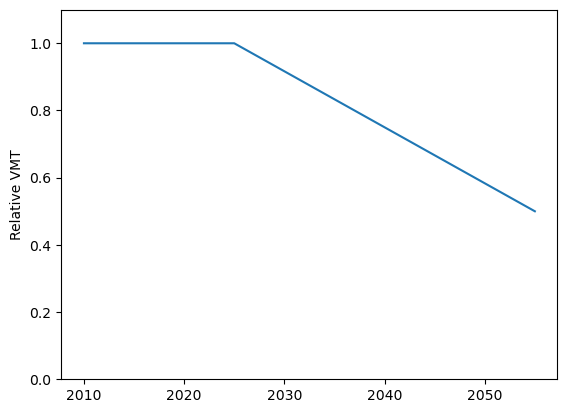

In [36]:
step = 0.5/30 # decrease 50% over 30 years.
vmt_rel = np.concat([np.ones(15), np.arange(1, 0.5-step, -step)])
# This concatenates a constant array with 15 values of 1 with a decreasing range.
# Note you have to put both arrays into a list using the brackets and pass as a single argument to np.concat.

plt.plot(yyyy, vmt_rel)
plt.ylim([0, 1.1]) # y-axis should generally start at zero when looking at percents so as to not over-emphasize changes!
plt.ylabel('Relative VMT')

Now we can recalculate the cumulative emissions assuming our VMT reduction scenario.

In [37]:
vehicle_fleet_ghgs_vmtred = vehicle_fleet_ghgs.apply(lambda x: x * vmt_rel)
# Here we use an "apply" function to get pandas to line up the variables correctly.
# The "lambda" notation means define an inline function on x.
# This means that for every column, we'll multiply it by vmt_rel and return a new dataframe with the same shape as vehicle_fleet_ghgs.
vehicle_fleet_ghgs_vmtred.sum() / 1e9

gas    29.472997
EV      0.000000
dtype: float64

We've saved a few billion tonnes from the electrification-only case.

We can also look at the % savings post-2025.

In [38]:
vehicle_fleet_ghgs_vmtred.loc[2026:].sum().sum() / 1e9

np.float64(12.615396666666657)

In [39]:
1 - vehicle_fleet_ghgs_vmtred.loc[2026:].sum().sum() / vehicle_fleet_ghgs.loc[2026:].sum().sum()

np.float64(0.1447420634920641)

We've saved 14% of the GHGs from here on out. Not bad, but maybe a bit disappointing given how aggressive this VMT reduction scenario is...

But we're counting the benefits of the VMT reduction conservatively, because we're only looking at direct tailpipe GHGs.
How much greater are the benefits if we include vehicle and fuel lifecycle emissions for both the gasoline vehicles and EVs?

## 4) Homework exercises

### 4a) Part I: Sector cumulative emission budgets

Let's start with our three projections from 2026-on:
- 31.6 billion tonnes CO$_2$  in zero-electrification baseline
- 14.8 billion tonnes under ambitious electrification but not VMT reduction
- 12.6 billion tonnes CO$_2$ *with* VMT reduction.

How do these compare with the global carbon budgets consistent with 1.7$\degree$C and with 2$\degree$C, downscaled to the country and sector?

There are two simple ways to define a sector carbon budget, representing bookends [see, e.g., Teplin et al [(2021)](https://rmi.org/resources/scaling-us-climate-ambitions/) or Rankin et al [(2026)](https://www.nature.com/articles/s44284-025-00379-8)]
from the readings.]

The first is to downscale the budget based on the current share of global emissions. Here, we would divide US light-duty vehicle (LDV) emissions by the global CO$_2$
emissions in 2025 to define the country and sector's share of the total cumulative carbon budget. This is known as a "grandfathering" approach because it allocates
more carbon to historically larger emission sources.

The second is to downscale by the sector's share of global CO$_2$, and then by country's share of global population. This approach is more geopolitically fair because it assigns the same share to people in less wealthy and less-polluting countries, but it requires extremely fast reductions in wealthy countries.

**How do the cumulative emissions compare with a sector carbon budget using each of these approaches, for both 1.7$\degree$C and for 2$\degree$C?**

You will need to look up estimates for national vs. global LDV emissions here (sometimes reported as passenger vehicles, which are nearly identical to LDVs in the US because total emissions from buses and 2-wheelers smaller than motorcycles are negligible). These may vary slightly (high-quality sub-sector data are surprisingly hard to find!). Cite your source, and make a reasonable assumption if you have trouble finding one.

### 4b) Part II: Lifecycle (i.e. Scopes 2-3) GHGs.

Now relax the direct (Scope 1) GHG accounting we've been using which only counts tailpipe GHGs from gasoline vehicles.

**If we include vehicle- and fuel-lifecycle GHG factors for both gasoline and electric vehicles, how much greater are the relative savings in our VMT reduction scenario?**

Use the per-mi emission factors defined in Subin et al [2024](https://journal-buildingscities.org/articles/10.5334/bc.434), simplifying by
using projected California 2033 values for each.

(If you're curious, you can find these in cells C16 and L48, on tab "Main Scenario" in Supplemental "File 2." These are 
sourced from CA GREET runs for the LCFS regulation, ICCT's 2021 estimates of vehicle manufacturing GHGs, and an NREL Cambium "Mid-case" scenario for projected
grid emissions intensities; these data are a bit out of date but good enough for this exercise.)

- 184 g CO$_2$/mi for upstream emissions (i.e., in addition to direct emissions defined above) from petroleum extraction and refining plus vehicle manufacturing for gasoline vehicles;
-  62 g CO$_2$/mi for upstream emissions from electricity and vehicle manufacturing for EVs.